In [1]:
import mysql.connector
from dotenv import load_dotenv
import os

# connect notebook to sql database

load_dotenv()

conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password=os.getenv('MYSQL_PASSWORD'),
    database='claims_practice'
)

print("Connection successful" if conn.is_connected() else "Connection failed")

Connection successful


In [2]:
import pandas as pd

# Load and execute 06_readmission_by_drg.sql against the claims_practice database.

with open('../queries/06_readmission_by_drg.sql', 'r') as f:
    query = f.read()
df = pd.read_sql(query, conn)
df['readmission_count'] = df['readmission_count'].astype(int)
print(df.head())


/var/folders/4_/dbg0kzhn7354xv35_by_4slr0000gn/T/ipykernel_45585/3091464475.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


  CLM_DRG_CD  readmission_rate  readmission_count  total_admissions
0        813             0.228                 13                57
1        665             0.195                 15                77
2        513             0.188                 15                80
3        815             0.186                 11                59
4        037             0.182                 14                77


In [3]:
# Add 95% confidence intervals to each DRG's readmission rate using the Wilson 
# score method. readmission_rate and total_admissions alone are point estimates 
# with no uncertainty attached — DRGs with small n (e.g. the HAVING-clause floor 
# of 10 readmissions) can show a rate that looks meaningfully different from 
# another DRG or a national benchmark, when the difference is actually within 
# normal sampling variability.
#
# Wilson (rather than the standard Wald interval) is used because it stays 
# reliable at small n and when p is near 0 or 1 — both common here given the 
# volume-threshold filtering already applied in the SQL query.

from statsmodels.stats.proportion import proportion_confint

df['ci_lower'], df['ci_upper'] = proportion_confint(
    count=df['readmission_count'], 
    nobs=df['total_admissions'], 
    alpha=0.05, 
    method='wilson'
)

In [4]:
df[['CLM_DRG_CD', 'readmission_rate', 'readmission_count', 'total_admissions', 'ci_lower', 'ci_upper']].head(10)

,CLM_DRG_CD,readmission_rate,readmission_count,total_admissions,ci_lower,ci_upper
0,813,0.228,13,57,0.138419,0.352060
1,665,0.195,15,77,0.121764,0.296851
2,513,0.188,15,80,0.117053,0.286583
3,815,0.186,11,59,0.107427,0.303790
4,037,0.182,14,77,0.111513,0.282363
5,033,0.175,10,57,0.098189,0.293674
6,099,0.172,11,64,0.098777,0.282132
7,601,0.169,10,59,0.094758,0.284632
8,495,0.169,11,65,0.097212,0.278164
9,102,0.167,12,72,0.097994,0.269107


## Benchmark Reference
All-cause 30-day hospital readmission rate benchmark: 14.67%

Source: Definitive Healthcare. (2025, March). *Average hospital readmission rate by state*. 
Data originally sourced from CMS. 
https://www.definitivehc.com/resources/healthcare-insights/average-hospital-readmission-state

Note: This is an all-cause benchmark, not DRG-specific. A more precise comparison 
would require condition-specific rates from CMS HRRP published data.

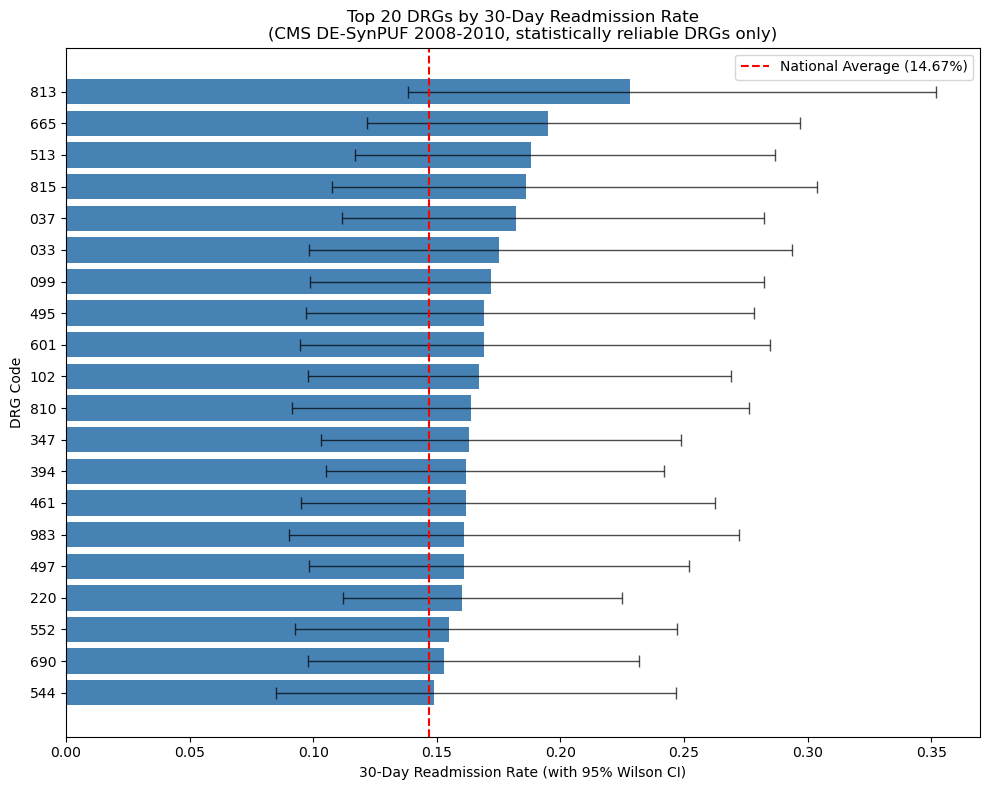

In [5]:
# Visualize the top 20 DRG readmission rates and compare against all cause national average
# Error bars show 95% Wilson confidence intervals — DRGs with wide bars have 
# small n and their rate should be interpreted with more caution, especially 
# where the interval crosses or nearly reaches the national average line.

import matplotlib.pyplot as plt

top20 = df.head(20).sort_values('readmission_rate')

# xerr needs asymmetric distances from the point estimate, not the raw CI bounds
lower_err = top20['readmission_rate'] - top20['ci_lower']
upper_err = top20['ci_upper'] - top20['readmission_rate']

plt.figure(figsize=(10, 8))
plt.barh(
    top20['CLM_DRG_CD'].astype(str), 
    top20['readmission_rate'], 
    xerr=[lower_err, upper_err],
    color='steelblue',
    capsize=4,
    error_kw={'ecolor': 'black', 'elinewidth': 1, 'alpha': 0.7}
)
plt.axvline(x=0.1467, color='red', linewidth=1.5, linestyle='--', label='National Average (14.67%)')
plt.legend()
plt.xlabel('30-Day Readmission Rate (with 95% Wilson CI)')
plt.ylabel('DRG Code')
plt.title('Top 20 DRGs by 30-Day Readmission Rate\n(CMS DE-SynPUF 2008-2010, statistically reliable DRGs only)')
plt.tight_layout()
plt.savefig('../images/top20_drg_readmission_rate.png', dpi=150, bbox_inches='tight')
plt.show()